## Air Quality Prediction using ANN in TensorFlow

### 1. Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### 2. Loading Dataset

In [2]:
url = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/52-Predicting%20Air%20Quality%20with%20NN/city_day.csv"

In [3]:
df = pd.read_csv(url)
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


### 3. Data Preprocessing

1. Exploratory Data Analysis

In [4]:
df.shape

(29531, 16)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,24933.0,67.450578,64.661449,0.04,28.820,48.57,80.5900,949.99
PM10,18391.0,118.127103,90.605110,0.01,56.255,95.68,149.7450,1000.00
NO,25949.0,17.574730,22.785846,0.02,5.630,9.89,19.9500,390.68
NO2,25946.0,28.560659,24.474746,0.01,11.750,21.69,37.6200,362.21
NOx,25346.0,32.309123,31.646011,0.00,12.820,23.52,40.1275,467.63
NH3,19203.0,23.483476,25.684275,0.01,8.580,15.85,30.0200,352.89
CO,27472.0,2.248598,6.962884,0.00,0.510,0.89,1.4500,175.81
SO2,25677.0,14.531977,18.133775,0.01,5.670,9.16,15.2200,193.86
O3,25509.0,34.491430,21.694928,0.01,18.860,30.84,45.5700,257.73
Benzene,23908.0,3.280840,15.811136,0.00,0.120,1.07,3.0800,455.03


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [9]:
df.dropna(axis=0, inplace=True)

In [10]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


In [18]:
df['Date'] = pd.to_datetime(df['Date'])


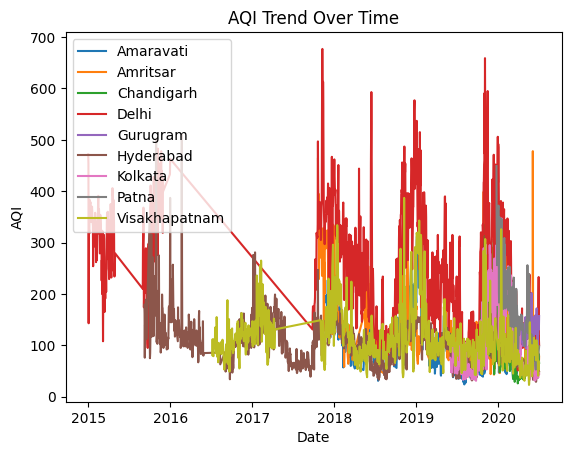

In [ ]:
for city in df['City'].unique():
    subset = df[df['City'] == city]
    plt.plot(subset['Date'], subset['AQI'], label=city)

plt.title("AQI Trend Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()

plt.show()

/tmp/ipykernel_46449/2194663154.py:3: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



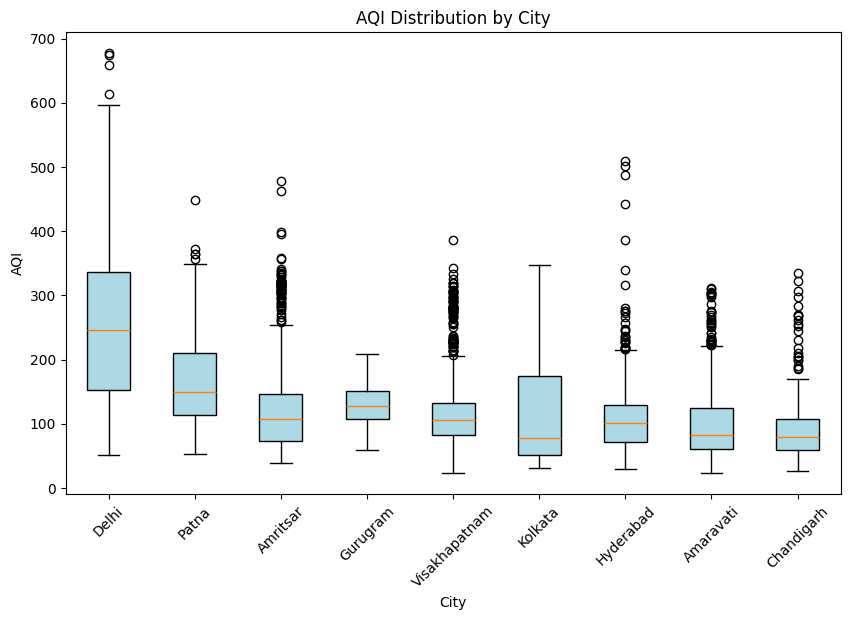

In [26]:
plt.figure(figsize=(10,6))

box = plt.boxplot(data, labels=city_order, patch_artist=True)

# add colors
for patch in box['boxes']:
    patch.set_facecolor('lightblue')

plt.title("AQI Distribution by City")
plt.xlabel("City")
plt.ylabel("AQI")
plt.xticks(rotation=45)

plt.show()

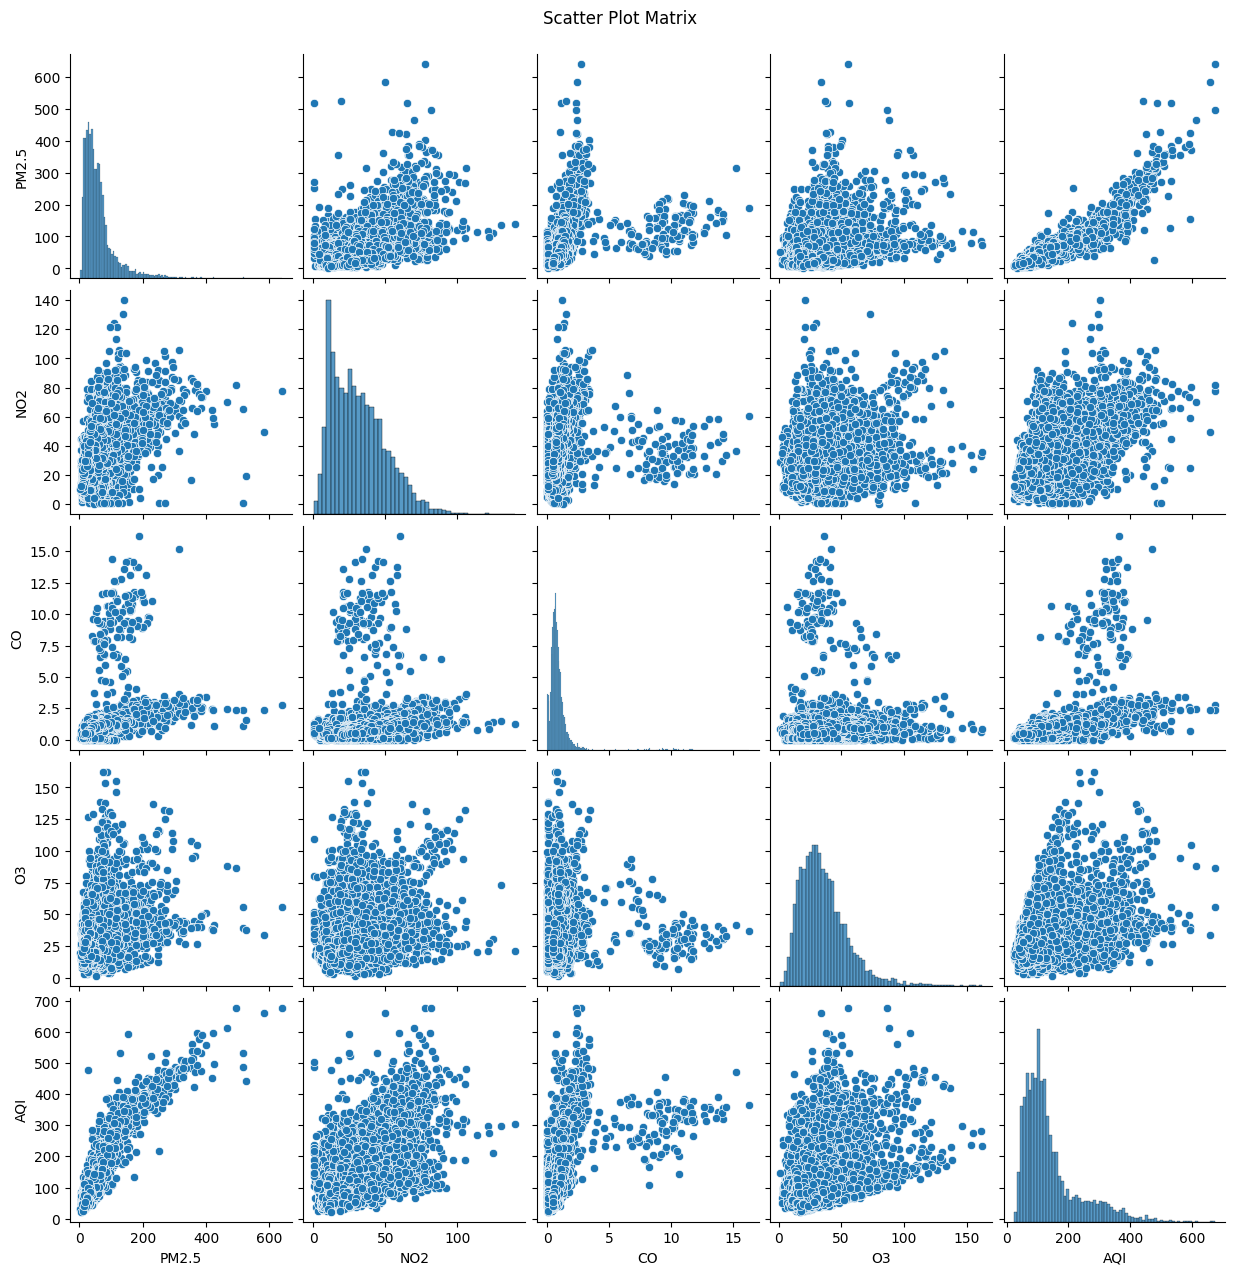

In [27]:
sns.pairplot(df[selected_features])
plt.suptitle("Scatter Plot Matrix", y=1.02)
plt.show()

2. Train Test Split

In [28]:
feature_columns = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
# Splitting the dataset into features (X) and target (y)
X = df[feature_columns]
y = df['AQI']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3. Feature Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Build the Model

In [32]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Compile and Fit the Model

In [33]:
X_test_scaled.shape

(1248, 12)

In [35]:
model.compile(
    optimizer='adam', 
    loss='mean_squared_error'
    )

# Training the model
history = model.fit(X_train_scaled, 
                    y_train, 
                    epochs=150, 
                    batch_size=32, 
                    validation_data=(X_test_scaled[:500], y_test[:500])
                    )

Epoch 1/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5304.9976 - val_loss: 3870.5396
Epoch 2/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2711.3906 - val_loss: 2510.2249
Epoch 3/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1698.7043 - val_loss: 1784.5431
Epoch 4/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1254.3459 - val_loss: 1454.7383
Epoch 5/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1074.5349 - val_loss: 1249.4475
Epoch 6/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 962.3455 - val_loss: 1125.5521
Epoch 7/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 899.6534 - val_loss: 1017.8432
Epoch 8/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 852.5362 - val_loss: 991.7699
Epoch 9/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 818.2095 - val_loss: 878.2117
Epoch 10/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 783.8607 - val_loss: 833.5873
Epoch 11/150
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 757.9380 - val_

### 6. Make Prediction

In [36]:
user_input = pd.DataFrame({
    'PM2.5': [81],
    'PM10': [124],
    'NO': [1.44],
    'NO2': [20],
    'NOx': [12],
    'NH3': [10],
    'CO': [0.1],
    'SO2': [15],
    'O3': [127],
    'Benzene': [0.20],
    'Toluene': [6],
    'Xylene': [0.06]
})

user_input_scaled = scaler.transform(user_input)

user_pred = model.predict(user_input_scaled)

print(f"Predicted AQI: {user_pred[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Predicted AQI: 186.11619567871094


### 7. Evaluate the Model

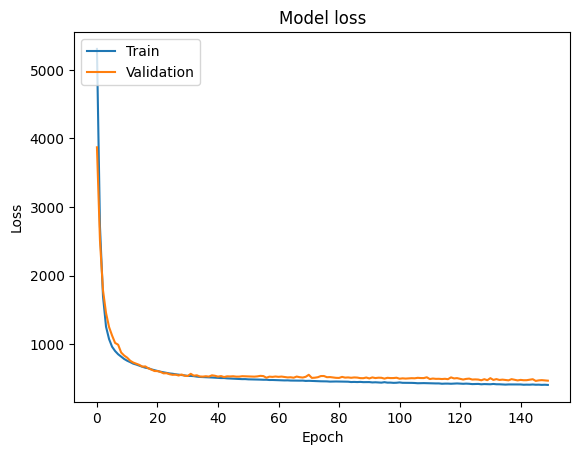

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 422.6846
Mean Squared Error on Test Data: 422.68463134765625


In [37]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model
loss = model.evaluate(X_test_scaled, y_test)
print("Mean Squared Error on Test Data:", loss)

### 8. Save Model

In [38]:
model.save('model.h5')

### 9. Load the Model and Test

In [39]:
from tensorflow.keras.models import load_model

new_model = load_model('model.h5')

In [40]:
new_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,947 (11.52 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [45]:
loss = new_model.evaluate(X_test_scaled, y_test)

print(f"Test Loss: {loss:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 422.6846
Test Loss: 422.6846
